# 🎯 LECTURES 9 & 10: CLASSIFICATION MASTERY
## From kNN to Logistic Regression!

**Goal**: Master classification algorithms that are the heart of HW3 and your midterm

**Topics Covered**:
- **Lecture 9**: k-Nearest Neighbors (kNN) Classification with Examples
- **Lecture 10**: Logistic Regression and the Logistic Function

**Why This Matters**: 
- **Classification predicts categories** (not continuous values like regression)
- **HW3 is entirely about classification** - this is your practice ground
- **Real applications**: Medical diagnosis, spam detection, image recognition


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris, make_classification
import seaborn as sns

print("🎯 LECTURES 9 & 10: CLASSIFICATION FUNDAMENTALS")
print()
print("🧠 BIG PICTURE:")
print("   Regression: Predicts NUMBERS (price, temperature, age)")
print("   Classification: Predicts CATEGORIES (spam/not spam, disease/healthy)")
print()
print("🎓 EXAM RELEVANCE:")
print("   • kNN: Core algorithm for HW3 Question 1")
print("   • Logistic Regression: HW3 Question 2")
print("   • Cross-validation: Model selection technique")
print("   • Confusion Matrix: Evaluation method")
print()
print("✅ Let's master classification!")


🎯 LECTURES 9 & 10: CLASSIFICATION FUNDAMENTALS

🧠 BIG PICTURE:
   Regression: Predicts NUMBERS (price, temperature, age)
   Classification: Predicts CATEGORIES (spam/not spam, disease/healthy)

🎓 EXAM RELEVANCE:
   • kNN: Core algorithm for HW3 Question 1
   • Logistic Regression: HW3 Question 2
   • Cross-validation: Model selection technique
   • Confusion Matrix: Evaluation method

✅ Let's master classification!


In [12]:
print(" 🎯 LECTURE 9: k-NEAREST NEIGHBORS (kNN)")

print("The Simplest Classification Algorithm")

print("🎯 k-NEAREST NEIGHBORS (kNN)")
print("The most intuitive classification algorithm!")
print()
print("🧠 THE BIG IDEA:")
print("   'Tell me who your neighbors are, and I'll tell you who you are'")
print()
print("📋 THE ALGORITHM:")
print("   1. Find the k closest points to your new point")
print("   2. Look at their labels")
print("   3. Vote! Majority wins")
print()
print("🌟 WHY IT WORKS:")
print("   Similar things should have similar labels")
print("   If you're surrounded by cats, you're probably a cat!")
print()
print("🎯 KEY PARAMETER:")
print("   k = number of neighbors to consider")
print("   k=1: Use only the closest neighbor")
print("   k=5: Use 5 closest neighbors and vote")


 🎯 LECTURE 9: k-NEAREST NEIGHBORS (kNN)
The Simplest Classification Algorithm
🎯 k-NEAREST NEIGHBORS (kNN)
The most intuitive classification algorithm!

🧠 THE BIG IDEA:
   'Tell me who your neighbors are, and I'll tell you who you are'

📋 THE ALGORITHM:
   1. Find the k closest points to your new point
   2. Look at their labels
   3. Vote! Majority wins

🌟 WHY IT WORKS:
   Similar things should have similar labels
   If you're surrounded by cats, you're probably a cat!

🎯 KEY PARAMETER:
   k = number of neighbors to consider
   k=1: Use only the closest neighbor
   k=5: Use 5 closest neighbors and vote


In [13]:
## 📊 Example 1: Simple kNN (Lecture 9 Style)

print("📊 EXAMPLE 1: Simple kNN Classification")
print("Let's recreate the exact example from Lecture 9!")

# Exact data from Lecture 9
X_simple = np.array([[1,1,3,4],
                     [2,1,5,5],
                     [5,5,1,2],
                     [5,4,1,3],
                     [5,5,1,1]])
Y_simple = np.array([1,2,3,4,5])

print(f"\n📋 Training Data:")
print(f"X (features):")
print(X_simple)
print(f"Y (labels): {Y_simple}")

# Create kNN classifier with k=1
knn_simple = KNeighborsClassifier(n_neighbors=1)
knn_simple.fit(X_simple, Y_simple)

# Test data from Lecture 9
T_simple = np.array([[1,2,3,1],
                     [5,3,2,1]])

predictions = knn_simple.predict(T_simple)

print(f"\n🧪 Test Data:")
print(f"T (new points to classify):")
print(T_simple)
print(f"Predictions: {predictions}")

# Let's understand WHY these predictions
print(f"\n🔍 WHY THESE PREDICTIONS?")
distances, indices = knn_simple.kneighbors(T_simple)

for i, test_point in enumerate(T_simple):
    nearest_idx = indices[i][0]  # Index of nearest neighbor
    nearest_distance = distances[i][0]  # Distance to nearest neighbor
    nearest_label = Y_simple[nearest_idx]  # Label of nearest neighbor
    
    print(f"\n📍 Test point {i+1}: {test_point}")
    print(f"   Nearest neighbor: {X_simple[nearest_idx]} (distance: {nearest_distance:.2f})")
    print(f"   Nearest neighbor's label: {nearest_label}")
    print(f"   → Prediction: {predictions[i]}")

print(f"\n✅ With k=1, we just copy the label of the closest training point!")


📊 EXAMPLE 1: Simple kNN Classification
Let's recreate the exact example from Lecture 9!

📋 Training Data:
X (features):
[[1 1 3 4]
 [2 1 5 5]
 [5 5 1 2]
 [5 4 1 3]
 [5 5 1 1]]
Y (labels): [1 2 3 4 5]

🧪 Test Data:
T (new points to classify):
[[1 2 3 1]
 [5 3 2 1]]
Predictions: [1 5]

🔍 WHY THESE PREDICTIONS?

📍 Test point 1: [1 2 3 1]
   Nearest neighbor: [1 1 3 4] (distance: 3.16)
   Nearest neighbor's label: 1
   → Prediction: 1

📍 Test point 2: [5 3 2 1]
   Nearest neighbor: [5 5 1 1] (distance: 2.24)
   Nearest neighbor's label: 5
   → Prediction: 5

✅ With k=1, we just copy the label of the closest training point!


🌸 EXAMPLE 2: Iris Dataset Classification
The most famous dataset in machine learning!

📊 Iris Dataset Info:
   Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
   Classes: ['setosa' 'versicolor' 'virginica']
   Data shape: (150, 4)
   Classes in data: [0 1 2]

📋 Data Split:
   Training set: 105 samples
   Test set: 45 samples

🧪 Testing Different k Values:
   k=1: Accuracy = 1.000
   k=3: Accuracy = 1.000
   k=5: Accuracy = 1.000
   k=7: Accuracy = 1.000
   k=9: Accuracy = 1.000

🏆 Best Result:
   Best k = 1
   Best accuracy = 1.000


/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/1590997638.py:76: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/1590997638.py:76: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


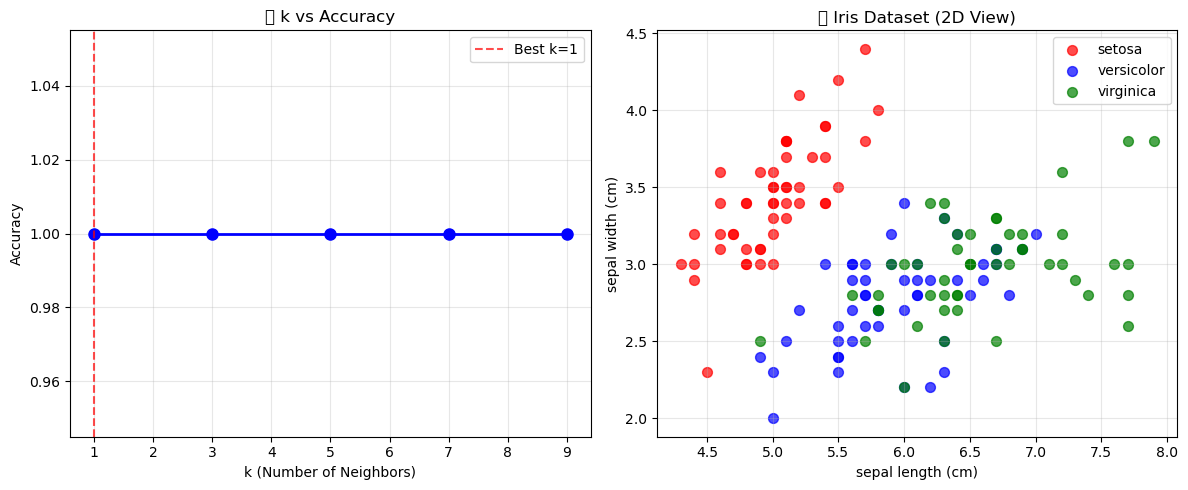


✅ kNN works great on Iris dataset!
   Different flower types cluster nicely in feature space


In [14]:
## 🌸 Example 2: Iris Dataset (The Classic!)

print("🌸 EXAMPLE 2: Iris Dataset Classification")
print("The most famous dataset in machine learning!")

# Load the Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print(f"\n📊 Iris Dataset Info:")
print(f"   Features: {iris.feature_names}")
print(f"   Classes: {iris.target_names}")
print(f"   Data shape: {X_iris.shape}")
print(f"   Classes in data: {np.unique(y_iris)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

print(f"\n📋 Data Split:")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")

# Try different k values
k_values = [1, 3, 5, 7, 9]
results = []

print(f"\n🧪 Testing Different k Values:")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append(accuracy)
    print(f"   k={k}: Accuracy = {accuracy:.3f}")

# Find best k
best_k = k_values[np.argmax(results)]
best_accuracy = max(results)

print(f"\n🏆 Best Result:")
print(f"   Best k = {best_k}")
print(f"   Best accuracy = {best_accuracy:.3f}")

# Visualize results
plt.figure(figsize=(12, 5))

# Left plot: k vs accuracy
plt.subplot(1, 2, 1)
plt.plot(k_values, results, 'bo-', linewidth=2, markersize=8)
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('🎯 k vs Accuracy')
plt.grid(True, alpha=0.3)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
plt.legend()

# Right plot: Feature visualization (2D projection)
plt.subplot(1, 2, 2)
# Use first two features for visualization
colors = ['red', 'blue', 'green']
for i, class_name in enumerate(iris.target_names):
    mask = y_iris == i
    plt.scatter(X_iris[mask, 0], X_iris[mask, 1], 
               c=colors[i], alpha=0.7, s=50, label=class_name)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('🌸 Iris Dataset (2D View)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ kNN works great on Iris dataset!")
print(f"   Different flower types cluster nicely in feature space")


🔄 CROSS-VALIDATION: The Professional Way
How to choose k without cheating!

🤔 THE PROBLEM:
   If we use test data to choose k, we're cheating!
   The test set should be saved for final evaluation

💡 THE SOLUTION:
   Use cross-validation on training data only
   Split training data into folds, test each k

🧪 Cross-Validation Results (5-fold):
   k=1: CV accuracy = 0.952 (±0.030)
   k=2: CV accuracy = 0.933 (±0.038)
   k=3: CV accuracy = 0.933 (±0.038)
   k=4: CV accuracy = 0.933 (±0.038)
   k=5: CV accuracy = 0.943 (±0.036)
   k=6: CV accuracy = 0.943 (±0.036)
   k=7: CV accuracy = 0.952 (±0.030)
   k=8: CV accuracy = 0.952 (±0.030)
   k=9: CV accuracy = 0.943 (±0.036)
   k=10: CV accuracy = 0.933 (±0.038)

🏆 Cross-Validation Results:
   Best k = 1
   Best CV accuracy = 0.952

🎯 Final Test Results:
   Test accuracy with k=1: 1.000


/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/2293691346.py:69: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


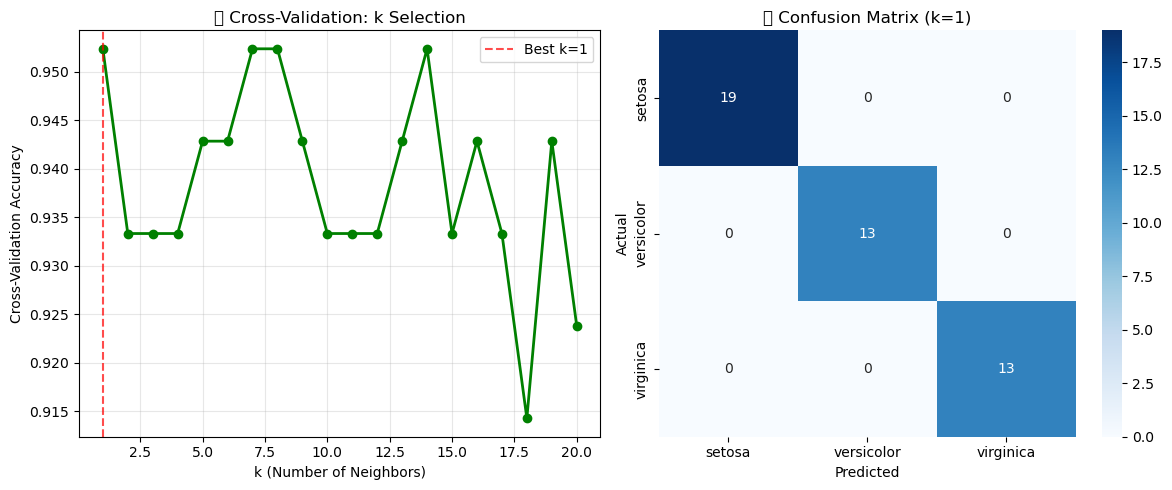


📊 CONFUSION MATRIX EXPLAINED:
   Diagonal = Correct predictions
   Off-diagonal = Mistakes
   Perfect classifier would have all values on diagonal

📋 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [15]:
## 🔄 Cross-Validation: The Right Way to Choose k

print("🔄 CROSS-VALIDATION: The Professional Way")
print("How to choose k without cheating!")
print()
print("🤔 THE PROBLEM:")
print("   If we use test data to choose k, we're cheating!")
print("   The test set should be saved for final evaluation")
print()
print("💡 THE SOLUTION:")
print("   Use cross-validation on training data only")
print("   Split training data into folds, test each k")

# Use only training data for k selection
k_values = range(1, 21)  # Test k from 1 to 20
cv_scores = []

print(f"\n🧪 Cross-Validation Results (5-fold):")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 5-fold cross-validation on TRAINING data only
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    mean_score = scores.mean()
    cv_scores.append(mean_score)
    
    if k <= 10:  # Print first 10 for brevity
        print(f"   k={k}: CV accuracy = {mean_score:.3f} (±{scores.std():.3f})")

# Find best k from cross-validation
best_k_cv = k_values[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)

print(f"\n🏆 Cross-Validation Results:")
print(f"   Best k = {best_k_cv}")
print(f"   Best CV accuracy = {best_cv_score:.3f}")

# Now test this k on the test set (final evaluation)
final_knn = KNeighborsClassifier(n_neighbors=best_k_cv)
final_knn.fit(X_train, y_train)
final_predictions = final_knn.predict(X_test)
final_accuracy = accuracy_score(y_test, final_predictions)

print(f"\n🎯 Final Test Results:")
print(f"   Test accuracy with k={best_k_cv}: {final_accuracy:.3f}")

# Visualize cross-validation results
plt.figure(figsize=(12, 5))

# Left plot: CV scores vs k
plt.subplot(1, 2, 1)
plt.plot(k_values, cv_scores, 'go-', linewidth=2, markersize=6)
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('🔄 Cross-Validation: k Selection')
plt.grid(True, alpha=0.3)
plt.axvline(x=best_k_cv, color='red', linestyle='--', alpha=0.7, 
           label=f'Best k={best_k_cv}')
plt.legend()

# Right plot: Confusion matrix for best model
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title(f'🎯 Confusion Matrix (k={best_k_cv})')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"\n📊 CONFUSION MATRIX EXPLAINED:")
print(f"   Diagonal = Correct predictions")
print(f"   Off-diagonal = Mistakes")
print(f"   Perfect classifier would have all values on diagonal")

# Detailed classification report
print(f"\n📋 DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, final_predictions, target_names=iris.target_names))


In [21]:
# 📈 LECTURE 10: LOGISTIC REGRESSION

## From Linear to Logistic: Handling Categories

print("📈 LECTURE 10: LOGISTIC REGRESSION")
print("When linear regression meets classification!")
print()
print("🤔 THE PROBLEM WITH LINEAR REGRESSION:")
print("   Linear regression predicts any number (-∞ to +∞)")
print("   But we need probabilities (0 to 1)")
print("   And categories (0 or 1, A or B or C)")
print()
print("💡 THE SOLUTION:")
print("   Use the LOGISTIC FUNCTION!")
print("   Squashes any number into range [0, 1]")
print()
print("🎯 KEY INSIGHT:")
print("   Logistic regression = Linear regression + Logistic function")
print("   Perfect for binary classification (yes/no, spam/ham)")


📈 LECTURE 10: LOGISTIC REGRESSION
When linear regression meets classification!

🤔 THE PROBLEM WITH LINEAR REGRESSION:
   Linear regression predicts any number (-∞ to +∞)
   But we need probabilities (0 to 1)
   And categories (0 or 1, A or B or C)

💡 THE SOLUTION:
   Use the LOGISTIC FUNCTION!
   Squashes any number into range [0, 1]

🎯 KEY INSIGHT:
   Logistic regression = Linear regression + Logistic function
   Perfect for binary classification (yes/no, spam/ham)


📊 THE LOGISTIC FUNCTION
The mathematical magic behind logistic regression!


/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/2233364640.py:67: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/2233364640.py:67: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/2233364640.py:67: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu

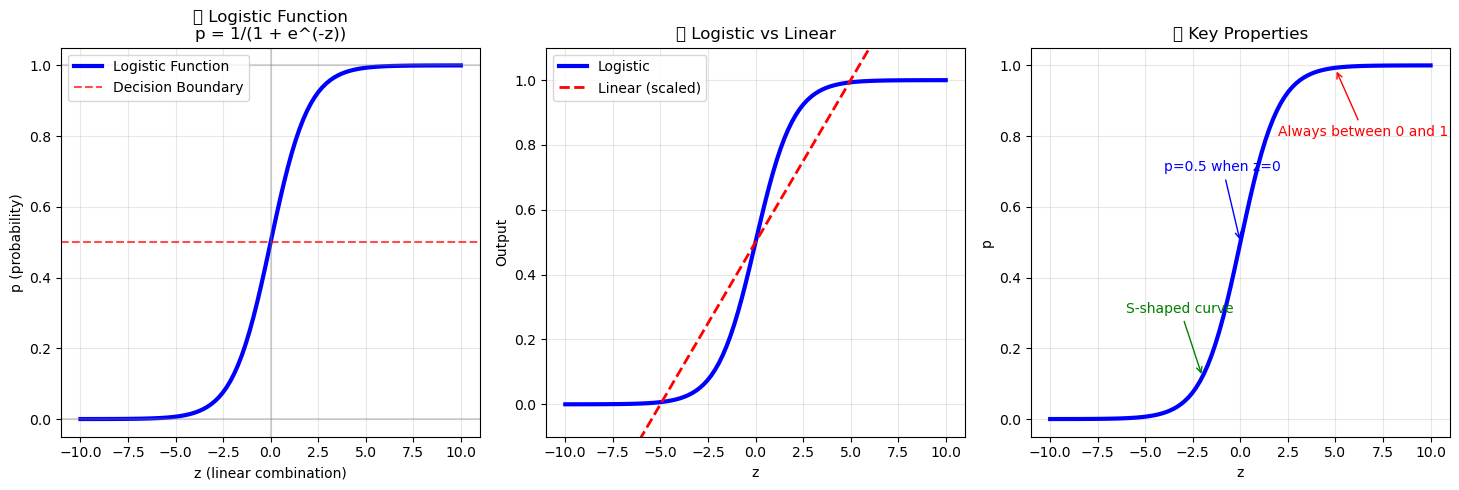

🧠 KEY INSIGHTS:
   • Input z can be any number (-∞ to +∞)
   • Output p is always between 0 and 1 (perfect for probabilities!)
   • When z = 0, p = 0.5 (decision boundary)
   • When z > 0, p > 0.5 (predict class 1)
   • When z < 0, p < 0.5 (predict class 0)

📋 THE FORMULA:
   z = β₀ + β₁x₁ + β₂x₂ + ... (linear part)
   p = 1/(1 + e^(-z)) (logistic part)
   prediction = 1 if p > 0.5, else 0


In [17]:
## 📊 The Logistic Function: The Magic Formula

print("📊 THE LOGISTIC FUNCTION")
print("The mathematical magic behind logistic regression!")

# Define the logistic function (sigmoid)
def logistic(z):
    """The logistic (sigmoid) function"""
    return np.exp(z) / (1 + np.exp(z))

# Alternative, more stable version
def logistic_stable(z):
    """Numerically stable logistic function"""
    return 1 / (1 + np.exp(-z))

# Create range of z values
z = np.linspace(-10, 10, 100)
y_logistic = logistic_stable(z)

# Plot the logistic function
plt.figure(figsize=(15, 5))

# Left plot: The logistic function
plt.subplot(1, 3, 1)
plt.plot(z, y_logistic, 'b-', linewidth=3, label='Logistic Function')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Decision Boundary')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axhline(y=1, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('z (linear combination)')
plt.ylabel('p (probability)')
plt.title('📈 Logistic Function\np = 1/(1 + e^(-z))')
plt.legend()
plt.grid(True, alpha=0.3)

# Middle plot: Compare with linear
plt.subplot(1, 3, 2)
plt.plot(z, y_logistic, 'b-', linewidth=3, label='Logistic')
plt.plot(z, z/10 + 0.5, 'r--', linewidth=2, label='Linear (scaled)')
plt.xlabel('z')
plt.ylabel('Output')
plt.title('🔄 Logistic vs Linear')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)

# Right plot: Key properties
plt.subplot(1, 3, 3)
plt.plot(z, y_logistic, 'b-', linewidth=3)

# Annotate key points
plt.annotate('Always between 0 and 1', xy=(5, 0.99), xytext=(2, 0.8),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')
plt.annotate('S-shaped curve', xy=(-2, 0.12), xytext=(-6, 0.3),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, color='green')
plt.annotate('p=0.5 when z=0', xy=(0, 0.5), xytext=(-4, 0.7),
            arrowprops=dict(arrowstyle='->', color='blue'),
            fontsize=10, color='blue')

plt.xlabel('z')
plt.ylabel('p')
plt.title('🎯 Key Properties')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🧠 KEY INSIGHTS:")
print("   • Input z can be any number (-∞ to +∞)")
print("   • Output p is always between 0 and 1 (perfect for probabilities!)")
print("   • When z = 0, p = 0.5 (decision boundary)")
print("   • When z > 0, p > 0.5 (predict class 1)")
print("   • When z < 0, p < 0.5 (predict class 0)")
print()
print("📋 THE FORMULA:")
print("   z = β₀ + β₁x₁ + β₂x₂ + ... (linear part)")
print("   p = 1/(1 + e^(-z)) (logistic part)")
print("   prediction = 1 if p > 0.5, else 0")


🏥 DIABETES PREDICTION: Real Medical Data
Using the Pima Indians Diabetes dataset from Lecture 10!

📊 Diabetes Dataset:
   Samples: 500
   Features: ['Glucose', 'BMI', 'Age']
   Diabetes cases: 387 (77.4%)
   Healthy cases: 113 (22.6%)

🎯 Logistic Regression Results:
   Training accuracy: 0.817
   Test accuracy: 0.787

📋 Learned Coefficients:
   Intercept (β₀): -5.891
   Glucose (β1): 0.050
   BMI (β2): 0.051
   Age (β3): 0.006


/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/1809762776.py:109: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/1809762776.py:109: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/1809762776.py:109: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarnin

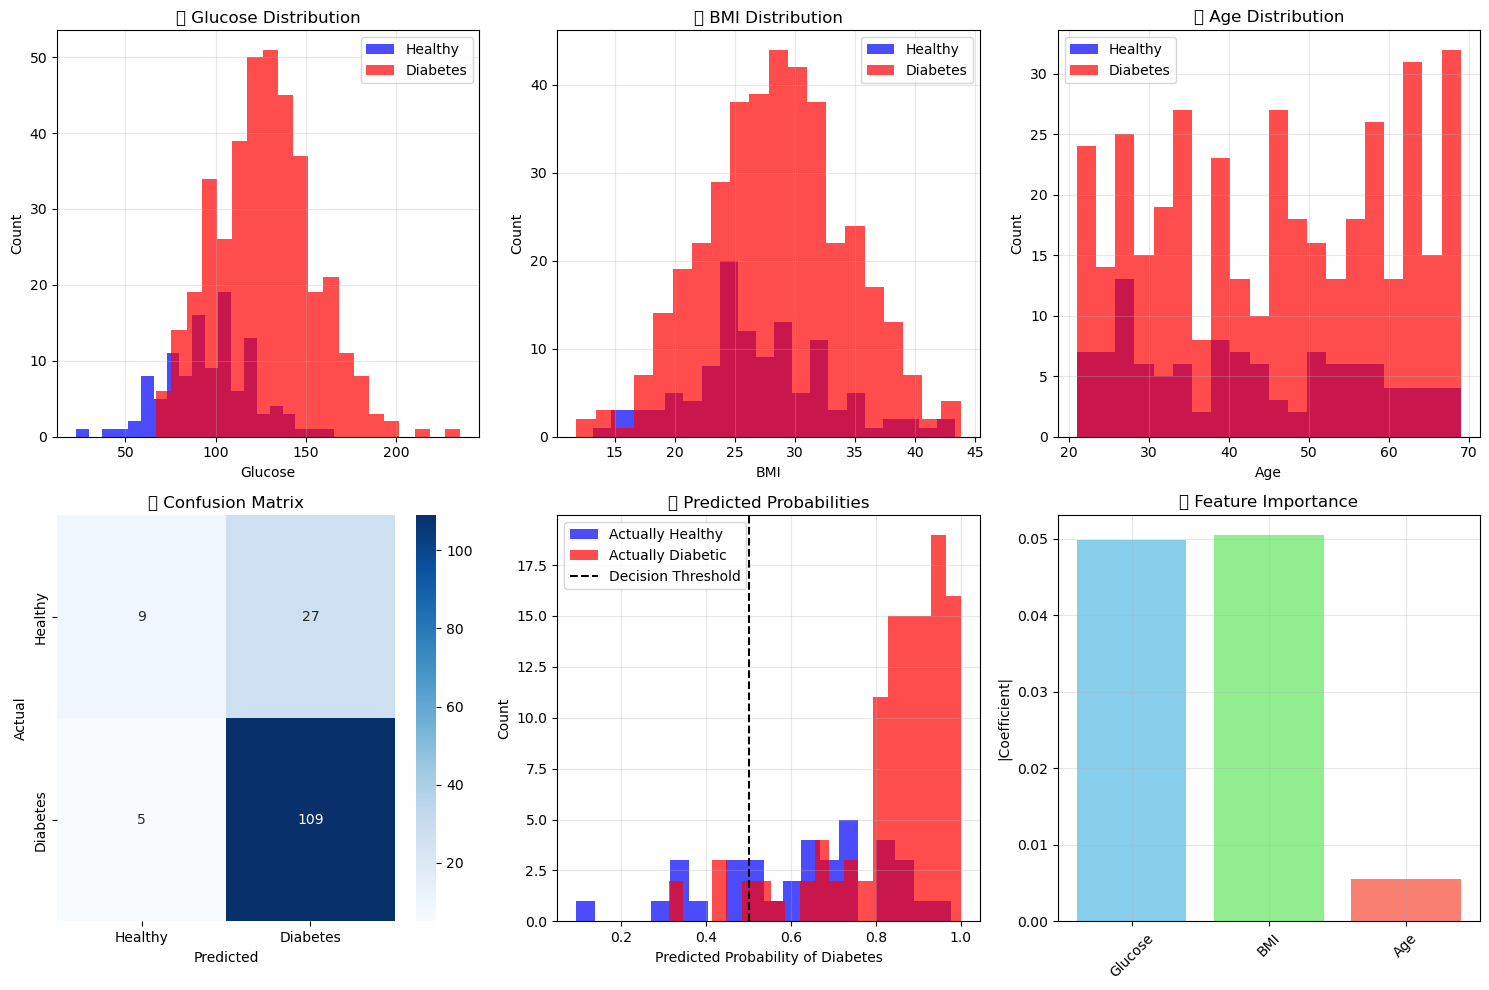


🔍 EXAMPLE PREDICTIONS:
   Patient 1: Glucose=166.0, BMI=18.9, Age=28
      → Diabetes probability: 0.970
      → Prediction: Diabetes
      → Actual: Diabetes
      → ✅ Correct

   Patient 2: Glucose=166.9, BMI=26.7, Age=64
      → Diabetes probability: 0.984
      → Prediction: Diabetes
      → Actual: Diabetes
      → ✅ Correct

   Patient 3: Glucose=184.6, BMI=27.8, Age=31
      → Diabetes probability: 0.992
      → Prediction: Diabetes
      → Actual: Diabetes
      → ✅ Correct

   Patient 4: Glucose=98.6, BMI=28.4, Age=40
      → Diabetes probability: 0.662
      → Prediction: Diabetes
      → Actual: Diabetes
      → ✅ Correct

   Patient 5: Glucose=115.2, BMI=30.5, Age=62
      → Diabetes probability: 0.849
      → Prediction: Diabetes
      → Actual: Diabetes
      → ✅ Correct



In [18]:
## 🏥 Example: Diabetes Prediction (Lecture 10 Style)

print("🏥 DIABETES PREDICTION: Real Medical Data")
print("Using the Pima Indians Diabetes dataset from Lecture 10!")

# Load the diabetes dataset (we'll create a simplified version)
# This mimics the dataset from Lecture 10
np.random.seed(42)
n_samples = 500

# Generate synthetic diabetes data similar to Pima Indians dataset
# Features: glucose, bmi, age (simplified version)
glucose = np.random.normal(120, 30, n_samples)
bmi = np.random.normal(28, 6, n_samples)
age = np.random.randint(21, 70, n_samples)

# Create diabetes labels based on realistic relationships
# Higher glucose, BMI, and age increase diabetes risk
diabetes_prob = logistic_stable(-8 + 0.05*glucose + 0.1*bmi + 0.02*age)
diabetes = np.random.binomial(1, diabetes_prob, n_samples)

# Combine features
X_diabetes = np.column_stack([glucose, bmi, age])
feature_names = ['Glucose', 'BMI', 'Age']

print(f"\n📊 Diabetes Dataset:")
print(f"   Samples: {n_samples}")
print(f"   Features: {feature_names}")
print(f"   Diabetes cases: {diabetes.sum()} ({diabetes.mean()*100:.1f}%)")
print(f"   Healthy cases: {(1-diabetes).sum()} ({(1-diabetes).mean()*100:.1f}%)")

# Split the data
X_train_diab, X_test_diab, y_train_diab, y_test_diab = train_test_split(
    X_diabetes, diabetes, test_size=0.3, random_state=42)

# Train logistic regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_diab, y_train_diab)

# Make predictions
y_pred_diab = log_reg.predict(X_test_diab)
y_pred_proba_diab = log_reg.predict_proba(X_test_diab)[:, 1]  # Probability of diabetes

# Calculate accuracy
accuracy_diab = accuracy_score(y_test_diab, y_pred_diab)

print(f"\n🎯 Logistic Regression Results:")
print(f"   Training accuracy: {log_reg.score(X_train_diab, y_train_diab):.3f}")
print(f"   Test accuracy: {accuracy_diab:.3f}")

# Show the learned coefficients
print(f"\n📋 Learned Coefficients:")
print(f"   Intercept (β₀): {log_reg.intercept_[0]:.3f}")
for i, feature in enumerate(feature_names):
    print(f"   {feature} (β{i+1}): {log_reg.coef_[0][i]:.3f}")

# Visualize results
plt.figure(figsize=(15, 10))

# Plot 1: Feature distributions by class
for i, feature in enumerate(feature_names):
    plt.subplot(2, 3, i+1)
    
    # Healthy patients
    healthy_data = X_diabetes[diabetes == 0, i]
    diabetic_data = X_diabetes[diabetes == 1, i]
    
    plt.hist(healthy_data, alpha=0.7, label='Healthy', bins=20, color='blue')
    plt.hist(diabetic_data, alpha=0.7, label='Diabetes', bins=20, color='red')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'📊 {feature} Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 4: Confusion Matrix
plt.subplot(2, 3, 4)
cm_diab = confusion_matrix(y_test_diab, y_pred_diab)
sns.heatmap(cm_diab, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Healthy', 'Diabetes'], 
           yticklabels=['Healthy', 'Diabetes'])
plt.title('🎯 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot 5: Probability distribution
plt.subplot(2, 3, 5)
healthy_probs = y_pred_proba_diab[y_test_diab == 0]
diabetic_probs = y_pred_proba_diab[y_test_diab == 1]

plt.hist(healthy_probs, alpha=0.7, label='Actually Healthy', bins=20, color='blue')
plt.hist(diabetic_probs, alpha=0.7, label='Actually Diabetic', bins=20, color='red')
plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold')
plt.xlabel('Predicted Probability of Diabetes')
plt.ylabel('Count')
plt.title('📈 Predicted Probabilities')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: Feature importance (coefficient magnitude)
plt.subplot(2, 3, 6)
coef_magnitude = np.abs(log_reg.coef_[0])
plt.bar(feature_names, coef_magnitude, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('|Coefficient|')
plt.title('📊 Feature Importance')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show some example predictions
print(f"\n🔍 EXAMPLE PREDICTIONS:")
for i in range(5):
    glucose_val = X_test_diab[i, 0]
    bmi_val = X_test_diab[i, 1]
    age_val = X_test_diab[i, 2]
    prob = y_pred_proba_diab[i]
    prediction = y_pred_diab[i]
    actual = y_test_diab[i]
    
    print(f"   Patient {i+1}: Glucose={glucose_val:.1f}, BMI={bmi_val:.1f}, Age={age_val:.0f}")
    print(f"      → Diabetes probability: {prob:.3f}")
    print(f"      → Prediction: {'Diabetes' if prediction == 1 else 'Healthy'}")
    print(f"      → Actual: {'Diabetes' if actual == 1 else 'Healthy'}")
    print(f"      → {'✅ Correct' if prediction == actual else '❌ Wrong'}")
    print()


🆚 kNN vs LOGISTIC REGRESSION: The Ultimate Comparison
Two powerful classification algorithms - which to choose?

🏆 PERFORMANCE COMPARISON:
   kNN (k=5) accuracy: 0.956
   Logistic Regression accuracy: 0.956


/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/551974591.py:95: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/551974591.py:95: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/rwhpd61s0_l7pqwb220n4nhw0000gn/T/ipykernel_16461/551974591.py:95: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages

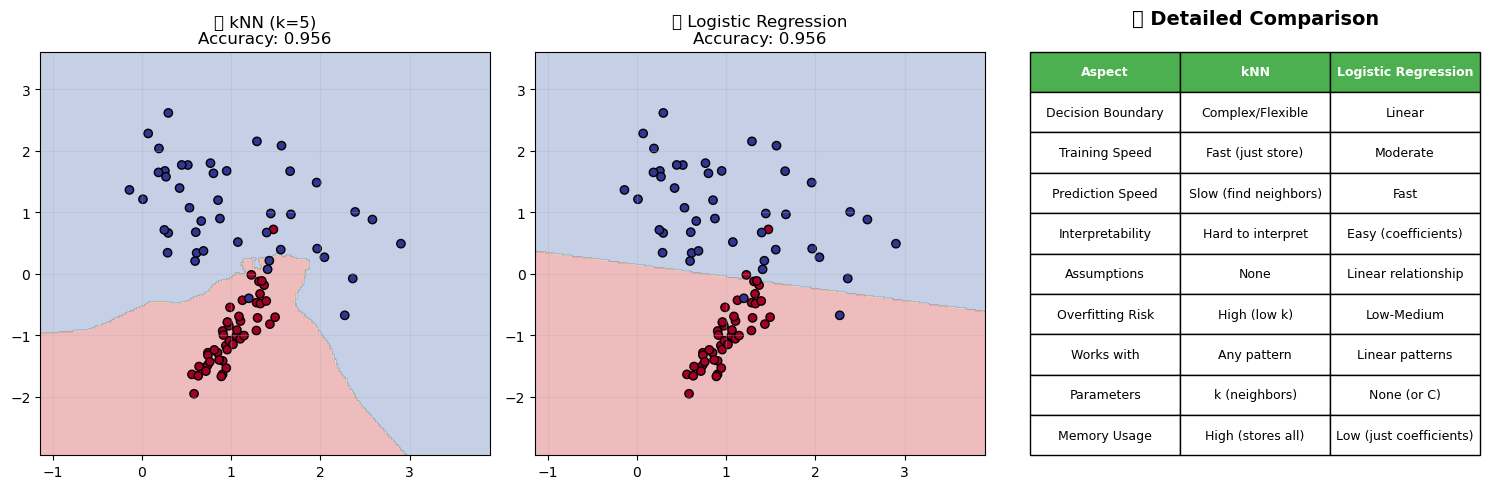


🎯 WHEN TO USE WHICH?

🎯 Use kNN when:
   • Data has complex, non-linear patterns
   • You have lots of training data
   • You don't need to understand the model
   • Prediction speed is not critical

📈 Use Logistic Regression when:
   • You need fast predictions
   • You want to understand feature importance
   • Data has roughly linear decision boundary
   • You need probability estimates
   • Memory is limited

🔄 CROSS-VALIDATION COMPARISON:
   kNN CV accuracy: 0.962 (±0.032)
   Logistic CV accuracy: 0.914 (±0.039)

✅ Both are excellent algorithms - choice depends on your specific problem!


In [19]:
## 🆚 kNN vs Logistic Regression: When to Use Which?

print("🆚 kNN vs LOGISTIC REGRESSION: The Ultimate Comparison")
print("Two powerful classification algorithms - which to choose?")

# Create a comparison dataset
np.random.seed(42)
X_comp, y_comp = make_classification(n_samples=300, n_features=2, n_redundant=0, 
                                    n_informative=2, n_clusters_per_class=1, 
                                    random_state=42)

# Split data
X_train_comp, X_test_comp, y_train_comp, y_test_comp = train_test_split(
    X_comp, y_comp, test_size=0.3, random_state=42)

# Train both models
knn_comp = KNeighborsClassifier(n_neighbors=5)
logistic_comp = LogisticRegression(random_state=42)

knn_comp.fit(X_train_comp, y_train_comp)
logistic_comp.fit(X_train_comp, y_train_comp)

# Make predictions
knn_pred = knn_comp.predict(X_test_comp)
logistic_pred = logistic_comp.predict(X_test_comp)

# Calculate accuracies
knn_accuracy = accuracy_score(y_test_comp, knn_pred)
logistic_accuracy = accuracy_score(y_test_comp, logistic_pred)

print(f"\n🏆 PERFORMANCE COMPARISON:")
print(f"   kNN (k=5) accuracy: {knn_accuracy:.3f}")
print(f"   Logistic Regression accuracy: {logistic_accuracy:.3f}")

# Visualize decision boundaries
def plot_decision_boundary(model, X, y, title, ax):
    """Plot decision boundary for a classifier"""
    h = 0.02  # Step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='black')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return scatter

plt.figure(figsize=(15, 5))

# Plot kNN decision boundary
plt.subplot(1, 3, 1)
plot_decision_boundary(knn_comp, X_test_comp, y_test_comp, 
                      f'🎯 kNN (k=5)\nAccuracy: {knn_accuracy:.3f}', plt.gca())

# Plot Logistic Regression decision boundary
plt.subplot(1, 3, 2)
plot_decision_boundary(logistic_comp, X_test_comp, y_test_comp, 
                      f'📈 Logistic Regression\nAccuracy: {logistic_accuracy:.3f}', plt.gca())

# Comparison table
plt.subplot(1, 3, 3)
plt.axis('off')

comparison_data = [
    ['Aspect', 'kNN', 'Logistic Regression'],
    ['Decision Boundary', 'Complex/Flexible', 'Linear'],
    ['Training Speed', 'Fast (just store)', 'Moderate'],
    ['Prediction Speed', 'Slow (find neighbors)', 'Fast'],
    ['Interpretability', 'Hard to interpret', 'Easy (coefficients)'],
    ['Assumptions', 'None', 'Linear relationship'],
    ['Overfitting Risk', 'High (low k)', 'Low-Medium'],
    ['Works with', 'Any pattern', 'Linear patterns'],
    ['Parameters', 'k (neighbors)', 'None (or C)'],
    ['Memory Usage', 'High (stores all)', 'Low (just coefficients)']
]

table = plt.table(cellText=comparison_data[1:], colLabels=comparison_data[0],
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Color header
for i in range(3):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

plt.title('📊 Detailed Comparison', pad=20, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🎯 WHEN TO USE WHICH?")
print(f"\n🎯 Use kNN when:")
print(f"   • Data has complex, non-linear patterns")
print(f"   • You have lots of training data")
print(f"   • You don't need to understand the model")
print(f"   • Prediction speed is not critical")
print(f"\n📈 Use Logistic Regression when:")
print(f"   • You need fast predictions")
print(f"   • You want to understand feature importance")
print(f"   • Data has roughly linear decision boundary")
print(f"   • You need probability estimates")
print(f"   • Memory is limited")

# Cross-validation comparison
print(f"\n🔄 CROSS-VALIDATION COMPARISON:")
knn_cv_scores = cross_val_score(knn_comp, X_train_comp, y_train_comp, cv=5)
logistic_cv_scores = cross_val_score(logistic_comp, X_train_comp, y_train_comp, cv=5)

print(f"   kNN CV accuracy: {knn_cv_scores.mean():.3f} (±{knn_cv_scores.std():.3f})")
print(f"   Logistic CV accuracy: {logistic_cv_scores.mean():.3f} (±{logistic_cv_scores.std():.3f})")
print(f"\n✅ Both are excellent algorithms - choice depends on your specific problem!")


In [20]:
## 🎓 EXAM MASTERY CHECKLIST

print("🎓 LECTURES 9 & 10: EXAM MASTERY CHECKLIST")
print()
print("✅ LECTURE 9 MASTERY (kNN Classification):")
print("   □ Can you explain the kNN algorithm in simple terms?")
print("   □ Do you know how to choose k using cross-validation?")
print("   □ Can you implement kNN with sklearn?")
print("   □ Do you understand the bias-variance trade-off for k?")
print("   □ Can you interpret confusion matrices?")
print()
print("✅ LECTURE 10 MASTERY (Logistic Regression):")
print("   □ Can you explain the logistic function?")
print("   □ Do you understand why we can't use linear regression for classification?")
print("   □ Can you interpret logistic regression coefficients?")
print("   □ Do you know how to get probability predictions?")
print("   □ Can you implement logistic regression in sklearn?")
print()
print("🎯 KEY FORMULAS TO REMEMBER:")
print("   • kNN: Find k nearest neighbors, majority vote")
print("   • Logistic function: p = 1/(1 + e^(-z))")
print("   • Linear combination: z = β₀ + β₁x₁ + β₂x₂ + ...")
print("   • Decision rule: predict 1 if p > 0.5, else 0")
print()
print("🧠 CONCEPTUAL UNDERSTANDING:")
print("   • Classification vs Regression: Categories vs Numbers")
print("   • kNN: Non-parametric, flexible, memory-based")
print("   • Logistic: Parametric, interpretable, fast predictions")
print("   • Cross-validation: Proper way to select hyperparameters")
print("   • Confusion Matrix: Detailed evaluation beyond accuracy")

print("\n" + "="*60)
print("🏆 FINAL CHALLENGE: HW3 Preview!")
print()
print("📋 SCENARIO (Similar to HW3):")
print("   You have a medical dataset with patient features")
print("   Goal: Predict disease presence (binary classification)")
print("   Available algorithms: kNN and Logistic Regression")
print()
print("❓ QUESTIONS:")
print("   1. How would you choose the best k for kNN?")
print("   2. How do you interpret logistic regression coefficients?")
print("   3. Which evaluation metrics would you use?")
print("   4. How do you avoid overfitting?")
print("   5. When would you prefer kNN over logistic regression?")
print()
print("💡 ANSWERS:")
print("   1. Cross-validation on training data")
print("   2. Positive coef = increases probability, negative = decreases")
print("   3. Accuracy, confusion matrix, precision, recall")
print("   4. Cross-validation, proper train/test split")
print("   5. When decision boundary is complex/non-linear")
print()
print("✅ If you got these right, you're ready for HW3!")

# Create a mini HW3-style problem
print(f"\n🧠 MINI PRACTICE PROBLEM:")
print(f"Let's solve a classification problem step by step!")

# Generate a simple binary classification dataset
np.random.seed(42)
X_practice, y_practice = make_classification(n_samples=100, n_features=2, 
                                           n_redundant=0, n_informative=2,
                                           n_clusters_per_class=1, random_state=42)

# Split data
X_train_prac, X_test_prac, y_train_prac, y_test_prac = train_test_split(
    X_practice, y_practice, test_size=0.3, random_state=42)

print(f"Dataset: {X_practice.shape[0]} samples, {X_practice.shape[1]} features")
print(f"Classes: {np.unique(y_practice)} (binary classification)")
print(f"Training set: {X_train_prac.shape[0]} samples")
print(f"Test set: {X_test_prac.shape[0]} samples")

# Step 1: Try different k values for kNN
print(f"\nStep 1: Find best k for kNN using cross-validation")
k_range = range(1, 11)
best_k = 1
best_score = 0

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_prac, y_train_prac, cv=3)
    mean_score = scores.mean()
    if mean_score > best_score:
        best_score = mean_score
        best_k = k

print(f"Best k = {best_k} with CV accuracy = {best_score:.3f}")

# Step 2: Train both models
knn_final = KNeighborsClassifier(n_neighbors=best_k)
logistic_final = LogisticRegression(random_state=42)

knn_final.fit(X_train_prac, y_train_prac)
logistic_final.fit(X_train_prac, y_train_prac)

# Step 3: Evaluate on test set
knn_test_acc = knn_final.score(X_test_prac, y_test_prac)
logistic_test_acc = logistic_final.score(X_test_prac, y_test_prac)

print(f"\nStep 2: Test set evaluation")
print(f"kNN (k={best_k}) accuracy: {knn_test_acc:.3f}")
print(f"Logistic Regression accuracy: {logistic_test_acc:.3f}")

# Step 4: Confusion matrices
knn_pred = knn_final.predict(X_test_prac)
logistic_pred = logistic_final.predict(X_test_prac)

print(f"\nStep 3: Confusion matrices")
print(f"kNN confusion matrix:")
print(confusion_matrix(y_test_prac, knn_pred))
print(f"Logistic confusion matrix:")
print(confusion_matrix(y_test_prac, logistic_pred))

print(f"\n🎯 CONCLUSION:")
winner = "kNN" if knn_test_acc > logistic_test_acc else "Logistic Regression"
print(f"Best algorithm for this dataset: {winner}")
print(f"You just completed a mini version of HW3! 🎉")


🎓 LECTURES 9 & 10: EXAM MASTERY CHECKLIST

✅ LECTURE 9 MASTERY (kNN Classification):
   □ Can you explain the kNN algorithm in simple terms?
   □ Do you know how to choose k using cross-validation?
   □ Can you implement kNN with sklearn?
   □ Do you understand the bias-variance trade-off for k?
   □ Can you interpret confusion matrices?

✅ LECTURE 10 MASTERY (Logistic Regression):
   □ Can you explain the logistic function?
   □ Do you understand why we can't use linear regression for classification?
   □ Can you interpret logistic regression coefficients?
   □ Do you know how to get probability predictions?
   □ Can you implement logistic regression in sklearn?

🎯 KEY FORMULAS TO REMEMBER:
   • kNN: Find k nearest neighbors, majority vote
   • Logistic function: p = 1/(1 + e^(-z))
   • Linear combination: z = β₀ + β₁x₁ + β₂x₂ + ...
   • Decision rule: predict 1 if p > 0.5, else 0

🧠 CONCEPTUAL UNDERSTANDING:
   • Classification vs Regression: Categories vs Numbers
   • kNN: Non-param